<a href="https://colab.research.google.com/github/AliceNanL/BA820-project/blob/M4_Nan_Li/BA820_Childcare_M4_NanLi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load the dataset**

In [1]:
# Read datasets from Github
import pandas as pd

childcare_costs = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-05-09/childcare_costs.csv'
)

counties = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-05-09/counties.csv'
)

In [2]:
childcare_costs['county_fips_code'].value_counts()

,count
county_fips_code,
56045,11
1001,11
1003,11
1005,11
1007,11
...,...
1031,11
2195,10
2275,10


In [3]:
counties['county_name'].value_counts()

,count
county_name,
Washington County,30
Jefferson County,25
Franklin County,24
Lincoln County,23
Jackson County,23
...,...
Sabine Parish,1
Richland Parish,1
Red River Parish,1


In [4]:
counties.count()

,0
county_fips_code,3144
county_name,3144
state_name,3144
state_abbreviation,3144


In [5]:
counties[counties['county_name']=='Washington County']

,county_fips_code,county_name,state_name,state_abbreviation
64,1129,Washington County,Alabama,AL
183,5143,Washington County,Arkansas,AR
306,8121,Washington County,Colorado,CO
387,12133,Washington County,Florida,FL
537,13303,Washington County,Georgia,GA
595,16087,Washington County,Idaho,ID
690,17189,Washington County,Illinois,IL
785,18175,Washington County,Indiana,IN
881,19183,Washington County,Iowa,IA
989,20201,Washington County,Kansas,KS


Different states sometimes have counties with the same name. This reminds us of using county_fips_code for analysis.

In [6]:
childcare_costs['county_fips_code'] = childcare_costs['county_fips_code'].astype(str)
counties['county_fips_code'] = counties['county_fips_code'].astype(str)

merged_df = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='left'
)

In [7]:
merged_df['_merge'] = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='left',
    indicator=True
)['_merge']

merged_df['_merge'].value_counts()

,count
_merge,
both,34567
left_only,0
right_only,0


In [8]:
merged_df.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation,_merge
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL,both
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL,both
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL,both
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL,both
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL,both


In [9]:
merged_df = merged_df.drop(columns=['_merge'])

In [10]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  object 
 1   study_year                 34567 non-null  int64  
 2   unr_16                     34567 non-null  float64
 3   funr_16                    34567 non-null  float64
 4   munr_16                    34567 non-null  float64
 5   unr_20to64                 34567 non-null  float64
 6   funr_20to64                34567 non-null  float64
 7   munr_20to64                34567 non-null  float64
 8   flfpr_20to64               34567 non-null  float64
 9   flfpr_20to64_under6        34567 non-null  float64
 10  flfpr_20to64_6to17         34567 non-null  float64
 11  flfpr_20to64_under6_6to17  34567 non-null  float64
 12  mlfpr_20to64               34567 non-null  float64
 13  pr_f                       34567 non-null  flo

In [11]:
# make sure the county_fips_code has the unified format of 5 digits
merged_df['county_fips_code'] = merged_df['county_fips_code'].str.zfill(5)

In [12]:
merged_df['county_fips_code'].value_counts()

,count
county_fips_code,
56045,11
01001,11
01003,11
01005,11
01007,11
...,...
01031,11
02195,10
02275,10


To deal with the missing values of our core features - childcare cost variables, I impute the missing values with the medians.

In [13]:
df_imputed = merged_df.copy()
#impute the missing values with medians
df_imputed = df_imputed.fillna(df_imputed.median(numeric_only=True))

In [14]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  object 
 1   study_year                 34567 non-null  int64  
 2   unr_16                     34567 non-null  float64
 3   funr_16                    34567 non-null  float64
 4   munr_16                    34567 non-null  float64
 5   unr_20to64                 34567 non-null  float64
 6   funr_20to64                34567 non-null  float64
 7   munr_20to64                34567 non-null  float64
 8   flfpr_20to64               34567 non-null  float64
 9   flfpr_20to64_under6        34567 non-null  float64
 10  flfpr_20to64_6to17         34567 non-null  float64
 11  flfpr_20to64_under6_6to17  34567 non-null  float64
 12  mlfpr_20to64               34567 non-null  float64
 13  pr_f                       34567 non-null  flo

In [15]:
df_imputed.describe()


,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,78.824106,...,23.456238,7.634403,99.740792,91.118235,142.384424,127.469095,119.615990,111.020413,104.653548,102.720772
std,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,8.529813,...,7.956927,4.501044,28.629667,22.848012,44.687670,36.433895,32.068735,27.215108,24.846785,23.914409
min,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,74.400000,...,17.610000,4.410000,87.850000,80.000000,120.000000,109.620000,103.615000,98.080000,92.500000,90.100000
50%,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,79.450000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,84.225000,...,28.930000,9.920000,105.000000,97.550000,150.000000,135.000000,125.000000,119.715000,110.180000,108.130000
max,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


Check the labor force participation variables.

In [16]:
df_imputed[['flfpr_20to64','flfpr_20to64_under6',
            'flfpr_20to64_6to17',
             'flfpr_20to64_under6_6to17',
              'mlfpr_20to64']].describe()

,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,flfpr_20to64_under6_6to17,mlfpr_20to64
count,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,70.086125,68.821409,78.824106,66.940759,78.637814
std,7.696499,11.758088,8.529813,13.285061,10.802983
min,33.600000,0.000000,0.000000,0.000000,8.200000
25%,65.100000,62.600000,74.400000,59.800000,74.200000
50%,70.600000,69.600000,79.450000,67.660000,81.000000
75%,75.500000,76.100000,84.225000,75.200000,85.900000
max,100.000000,100.000000,100.000000,100.000000,100.000000


Check occupation type variables.


In [17]:
df_imputed[['emp_m',
           'memp_m',
           'femp_m',
            'emp_service',
          'memp_service',
          'femp_service',
         'emp_sales',
          'memp_sales',
          'femp_sales',
          'emp_n',
          'memp_n',
           'femp_n',
            'emp_p',
            'memp_p',
            'femp_p']].describe()

,emp_m,memp_m,femp_m,emp_service,memp_service,femp_service,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p
count,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,30.720191,26.495400,35.509491,17.909716,13.122111,23.424303,22.244044,13.660359,32.062036,13.076182,23.265887,1.369745,16.049861,23.456238,7.634403
std,6.503783,8.013214,6.073988,3.602868,4.476415,4.696024,3.352621,3.761803,4.480591,4.257660,6.763236,1.430796,5.935141,7.956927,4.501044
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.340000,20.945000,31.560000,15.590000,10.270000,20.410000,20.150000,11.210000,29.390000,10.200000,18.680000,0.590000,11.640000,17.610000,4.410000
50%,29.690000,25.190000,34.940000,17.580000,12.840000,23.090000,22.410000,13.680000,32.170000,12.560000,22.700000,0.990000,15.590000,23.400000,6.630000
75%,34.100000,30.720000,38.870000,19.780000,15.450000,26.010000,24.540000,16.240000,34.800000,15.340000,27.210000,1.650000,19.830000,28.930000,9.920000
max,74.030000,76.890000,100.000000,46.420000,56.330000,62.780000,50.770000,49.060000,100.000000,60.000000,80.240000,27.270000,72.850000,87.500000,66.480000


# **Preprocessing and EDA**

# **Relevant EDA from Previous Analysis**

## **Gender Earning Gaps**

<Axes: >

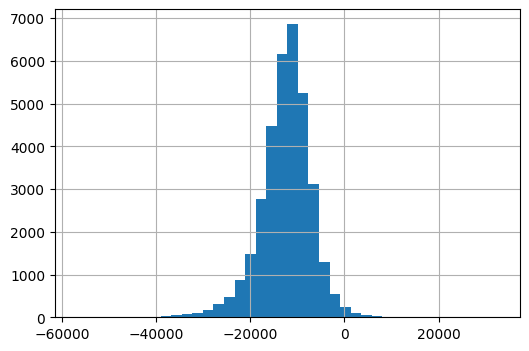

In [18]:
df_imputed['earnings_gap'] = df_imputed['fme_2018'] - df_imputed['mme_2018']
df_imputed['earnings_gap'].hist(bins=40, figsize=(6,4))

There's an inequality in earnings distribution, with women earning less than men since the distribution is not centered at zero but towards large negative values.

## **Labor Force Comparison**

<Axes: >

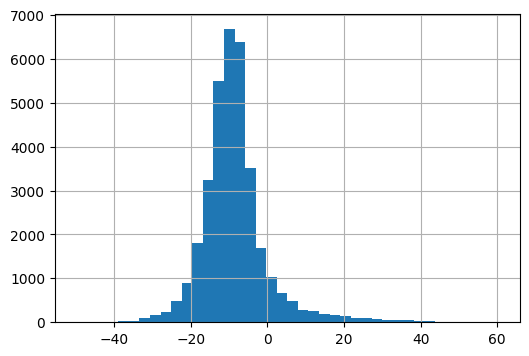

In [19]:
df_imputed['lfp_gap'] = df_imputed['flfpr_20to64'] - df_imputed['mlfpr_20to64']
df_imputed['lfp_gap'].hist(bins=40, figsize=(6,4))

The histogram indicates the labor force participation gap between males and females.

**Labor force participation of the female population ages 20–64, ages 20–64 with children under 6, and ages 20–64 with children ages 6–17**

<Axes: >

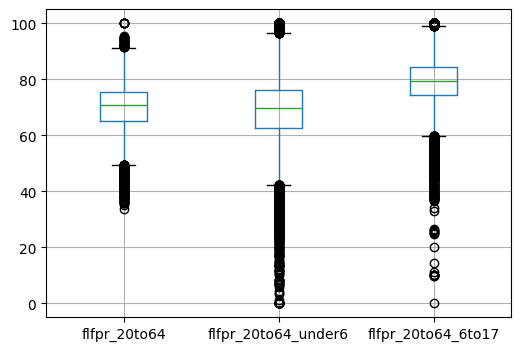

In [20]:
df_imputed[
    ['flfpr_20to64', 'flfpr_20to64_under6', 'flfpr_20to64_6to17']
].boxplot(figsize=(6,4))


The boxplots above indicate that from the three attributes, women ages 20-64 with children under 6 have the most outliers where there is very weak or no participation from them in the workforce.

## **Houeshold Composition**

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

household_cols = [
    'h_under6_both_work',
    'h_under6_f_work',
    'h_under6_m_work',
    'h_under6_single_m',
    'h_6to17_both_work',
    'h_6to17_fwork',
    'h_6to17_mwork',
    'h_6to17_single_m'
]

household_totals = df_imputed[household_cols].sum()

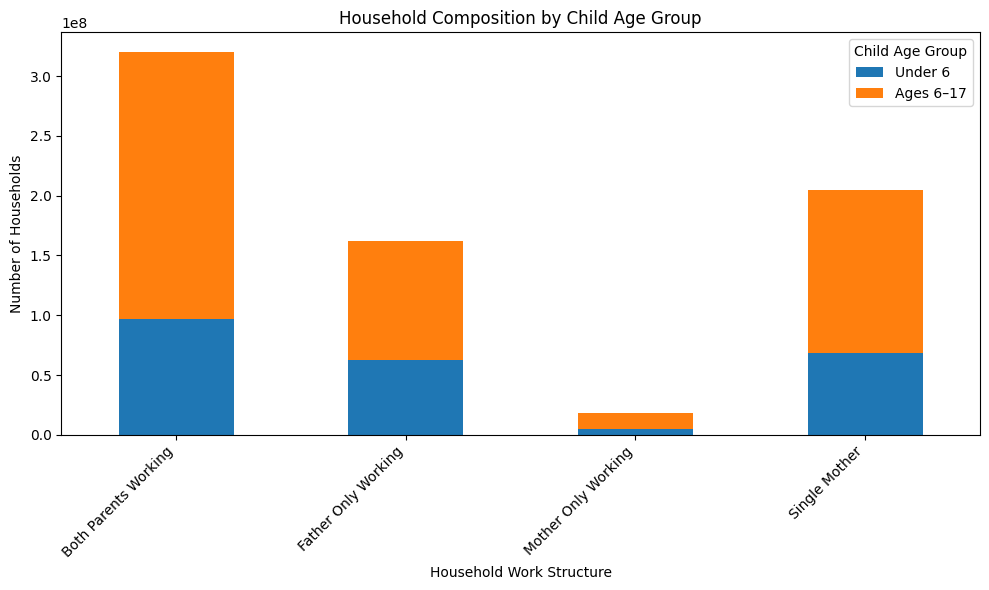

In [ ]:
household_df = pd.DataFrame({
    'Under 6': [
        household_totals['h_under6_both_work'],
        household_totals['h_under6_f_work'],
        household_totals['h_under6_m_work'],
        household_totals['h_under6_single_m']
    ],
    'Ages 6–17': [
        household_totals['h_6to17_both_work'],
        household_totals['h_6to17_fwork'],
        household_totals['h_6to17_mwork'],
        household_totals['h_6to17_single_m']
    ]
}, index=[
    'Both Parents Working',
    'Father Only Working',
    'Mother Only Working',
    'Single Mother'
])

household_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Household Composition by Child Age Group')
plt.ylabel('Number of Households')
plt.xlabel('Household Work Structure')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Child Age Group')
plt.tight_layout()
plt.show()


Households with children under six are less likely to have both parents working and more likely to rely on single-earner or single-mother arrangements, while households with children aged 6–17 are predominantly dual-earner, reflecting reduced childcare constraints as children reach school age. It is also important to note that father-only working households far outnumber mother-only working households in both age groups, highlighting persistent gender asymmetries in caregiving and labor force participation.

# **Updated EDA in M4**

To include analysis on the household composition, I decide to use convert the absolute number of households to percentage.

In [22]:
# convert household composition features to percentages with respective to the total numer of households
#this cell of code is generated with the Gemini assistance using comment function
household_cols = [
    'h_under6_both_work',
    'h_under6_f_work',
    'h_under6_m_work',
    'h_under6_single_m',
    'h_6to17_both_work',
    'h_6to17_fwork',
    'h_6to17_mwork',
    'h_6to17_single_m'
]
# Divide each household_cols by the feature-household and add the new features to the df_imputed
for col in household_cols:
    df_imputed[col+ '_perc'] = df_imputed[col] / df_imputed['households']*100

df_imputed.head()


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,earnings_gap,lfp_gap,h_under6_both_work_perc,h_under6_f_work_perc,h_under6_m_work_perc,h_under6_single_m_perc,h_6to17_both_work_perc,h_6to17_fwork_perc,h_6to17_mwork_perc,h_6to17_single_m_perc
0,01001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,-16280.55,-15.1,8.398193,5.279486,0.119741,5.415555,26.669569,7.119142,0.620476,10.700484
1,01001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,-17012.97,-15.4,8.065398,5.271216,0.087489,6.009405,27.493438,8.305993,0.503062,12.603893
2,01001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,-18764.16,-14.5,7.957196,5.117152,0.081144,5.629374,27.751293,7.815194,0.573080,12.054975
3,01001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,-18605.44,-15.5,8.475848,5.300530,0.530053,5.150515,25.327533,9.825983,1.230123,11.496150
4,01001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,-16308.60,-15.1,8.598375,4.705528,0.601987,5.493127,23.116284,9.847497,1.424702,13.263770


In [23]:
df_imputed.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,earnings_gap,lfp_gap,h_under6_both_work_perc,h_under6_f_work_perc,h_under6_m_work_perc,h_under6_single_m_perc,h_6to17_both_work_perc,h_6to17_fwork_perc,h_6to17_mwork_perc,h_6to17_single_m_perc
0,01001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,-16280.55,-15.1,8.398193,5.279486,0.119741,5.415555,26.669569,7.119142,0.620476,10.700484
1,01001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,-17012.97,-15.4,8.065398,5.271216,0.087489,6.009405,27.493438,8.305993,0.503062,12.603893
2,01001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,-18764.16,-14.5,7.957196,5.117152,0.081144,5.629374,27.751293,7.815194,0.573080,12.054975
3,01001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,-18605.44,-15.5,8.475848,5.300530,0.530053,5.150515,25.327533,9.825983,1.230123,11.496150
4,01001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,-16308.60,-15.1,8.598375,4.705528,0.601987,5.493127,23.116284,9.847497,1.424702,13.263770


In [24]:
for col in household_cols:
    print(f"Column: {col}_perc")
    display(df_imputed[col + '_perc'])
    print("\n")

Column: h_under6_both_work_perc


,h_under6_both_work_perc
0,8.398193
1,8.065398
2,7.957196
3,8.475848
4,8.598375
...,...
34562,10.113485
34563,10.549230
34564,9.668156
34565,9.050911




Column: h_under6_f_work_perc


,h_under6_f_work_perc
0,5.279486
1,5.271216
2,5.117152
3,5.300530
4,4.705528
...,...
34562,3.404539
34563,5.358339
34564,4.148054
34565,3.739786




Column: h_under6_m_work_perc


...

,h_6to17_fwork_perc
0,7.119142
1,8.305993
2,7.815194
3,9.825983
4,9.847497
...,...
34562,8.077437
34563,7.769591
34564,10.178685
34565,7.636706




Column: h_6to17_mwork_perc


,h_6to17_mwork_perc
0,0.620476
1,0.503062
2,0.573080
3,1.230123
4,1.424702
...,...
34562,0.000000
34563,0.000000
34564,0.000000
34565,0.000000




Column: h_6to17_single_m_perc


,h_6to17_single_m_perc
0,10.700484
1,12.603893
2,12.054975
3,11.496150
4,13.263770
...,...
34562,5.774366
34563,4.755526
34564,7.338864
34565,6.222502


By just checking the percentages of household structures, we can generate 2 basic insights:
1. Parents who have kids under 6 years old are less engaged in the labor market compared to the parents with school age children.
2. In general, regardless of the ages of the children, it is common that fathers(males) are the only working force if the household is single-earner family.This insight corresponds with the gender participation gap we observed earlier in our previous EDA.   

## **Occupation Types**

For occupation types, as we know from the previous EDA, there are gender earning gaps and larbor participation gaps, we would like to detect if there are correlation between occupation types and gender.

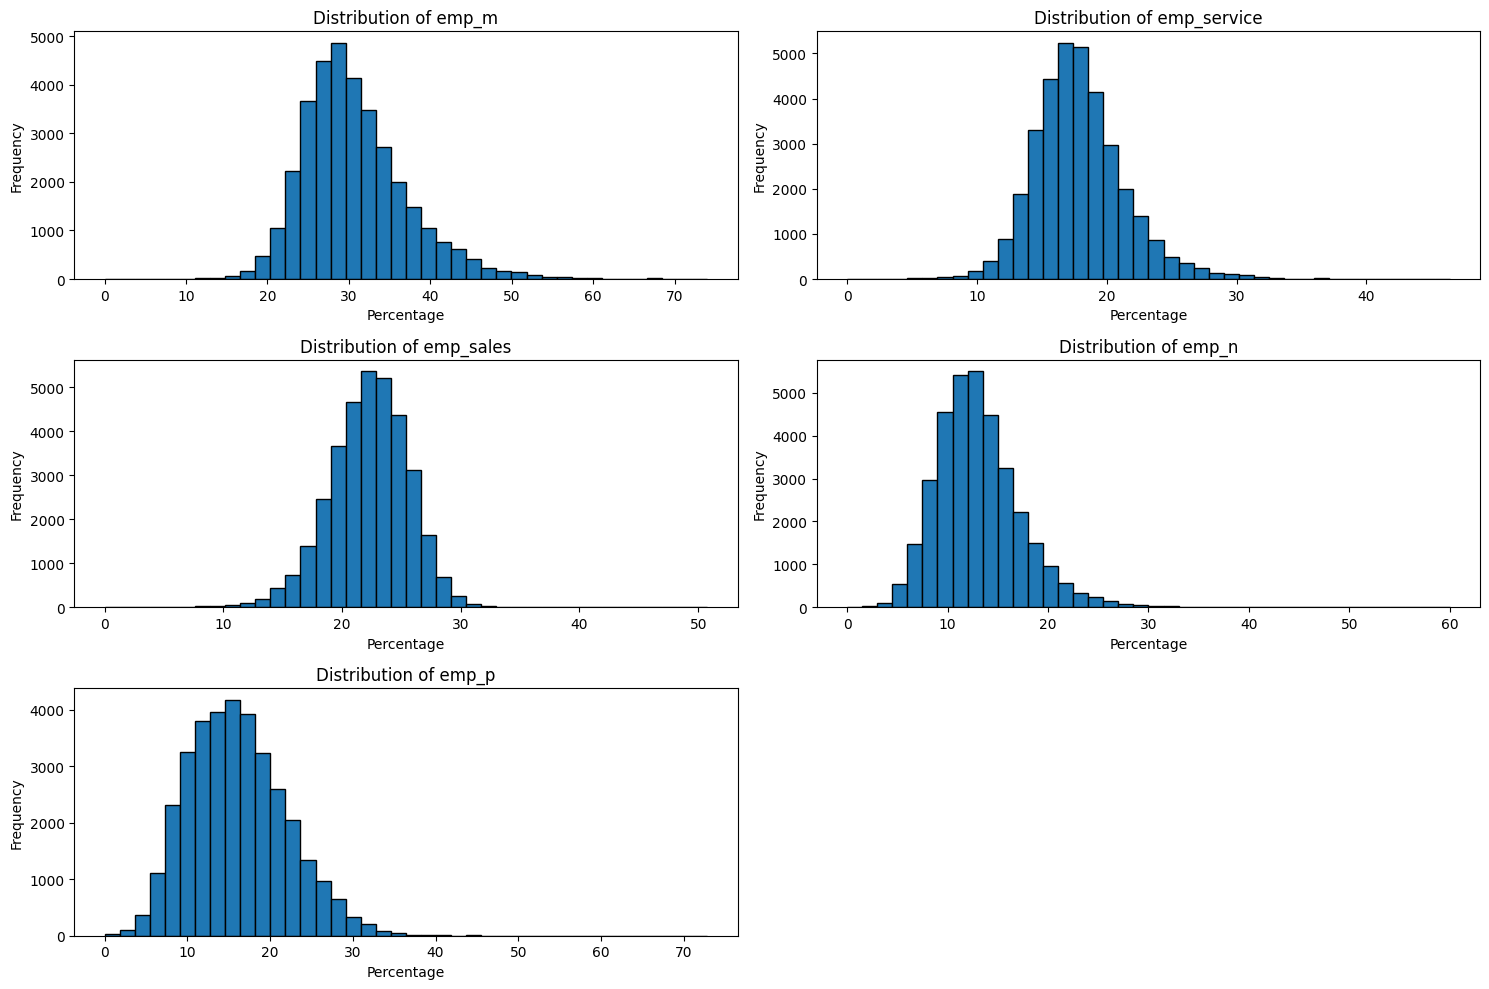

In [25]:
#This cell is generated with the Gemini using comments as shown in the cell.
# Check the distribution of occupation types
occupation_types = [
    'emp_m',
    'emp_service',
    'emp_sales',
    'emp_n',
    'emp_p'
]

# Plot the distribution of each occupation
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, type_col in enumerate(occupation_types):
    axes[i].hist(df_imputed[type_col], bins=40, edgecolor='black')
    axes[i].set_title(f'Distribution of {type_col}')
    axes[i].set_xlabel('Percentage')
    axes[i].set_ylabel('Frequency')

# Hide the last unused subplot since we only have 5 types
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Create the distribution plot of the percentage of male civilians in management across counties

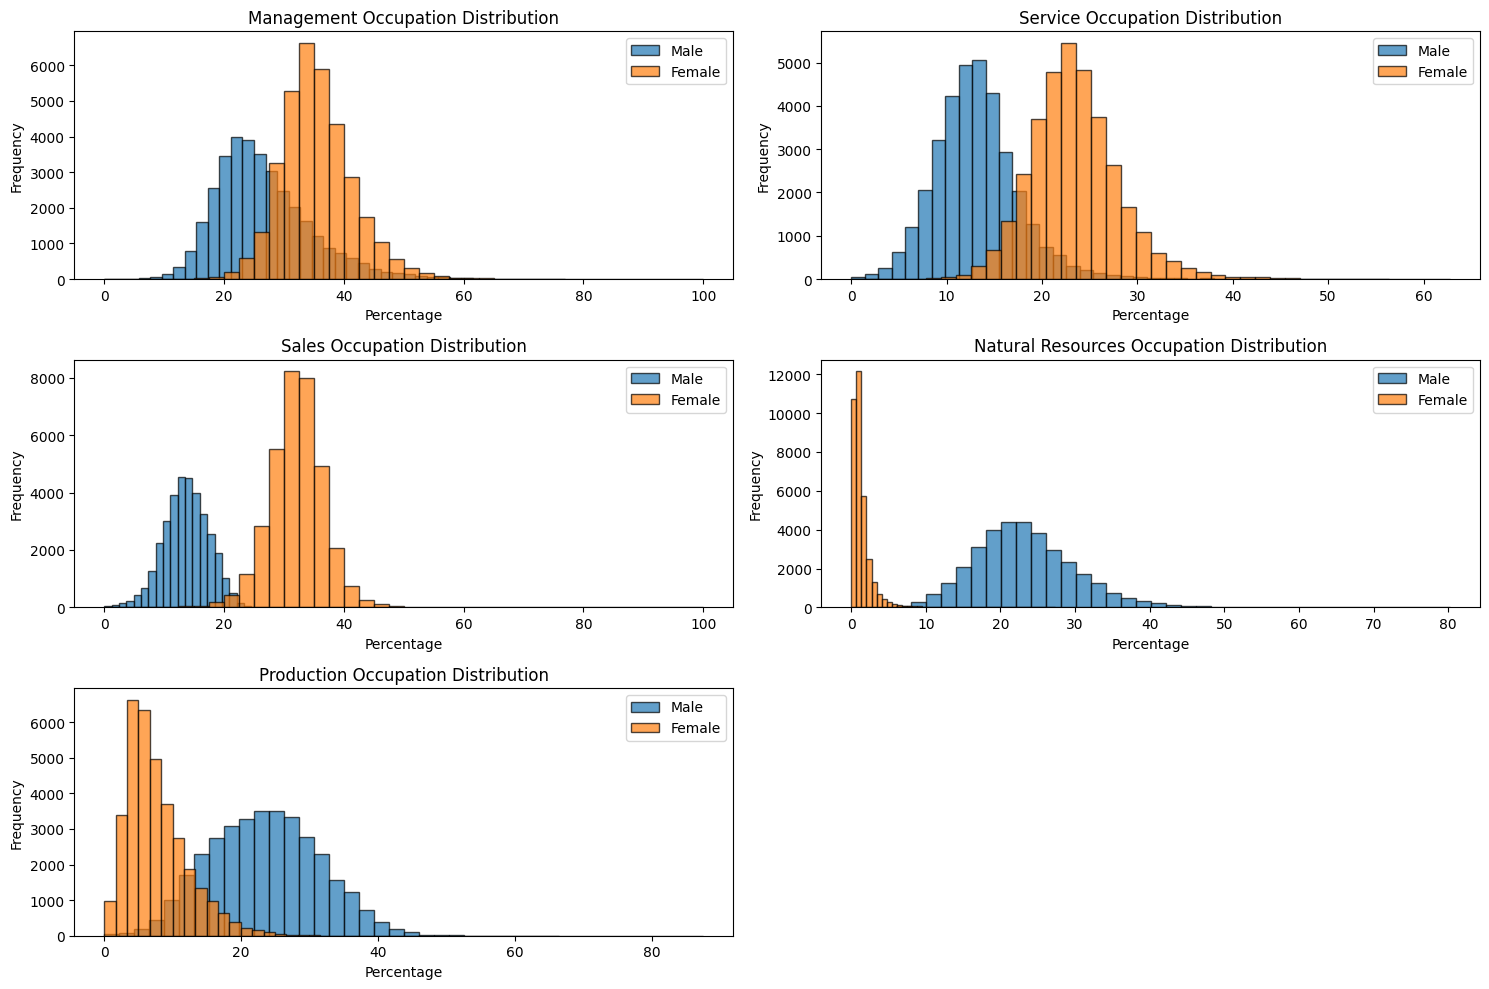

In [26]:
# For each type of occupation, plot distribution of percentages of male and female civilians in one subplot
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15,10))
axes = axes.flatten()

occupation_categories = {
    'Management': ['memp_m','femp_m'],
    'Service': ['memp_service','femp_service'],
    'Sales': ['memp_sales','femp_sales'],
    'Natural Resources': ['memp_n','femp_n'],
    'Production': ['memp_p','femp_p']
}

for i, (category_name, columns) in enumerate(occupation_categories.items()):
    ax = axes[i]
    male_col, female_col = columns

    ax.hist(df_imputed[male_col], bins=40, alpha=0.7, label='Male', edgecolor='black')
    ax.hist(df_imputed[female_col], bins=40, alpha=0.7, label='Female', edgecolor='black')

    ax.set_title(f'{category_name} Occupation Distribution')
    ax.set_xlabel('Percentage')
    ax.set_ylabel('Frequency')
    ax.legend()

# Hide any unused subplots
for j in range(len(occupation_categories), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We can observe from the plots above that gender disparity exists in occupation such as natural resources(construction) and sales. As we assume that gender gaps in labor participations and earnings might impact the household income.The exploratory insights on the gender difference in occupation types inspire us to include occupation types in our further analysis.

## **Childcare Affordability**

Based on our analysis from M3, regarding cost-related childcare type features, we found that infant, toddler, and preschool affordability ratios exhibited highly similar patterns. Including all of them as clustering dimensions would introduce redundancy. After examining the results more closely, we observed that toddler and preschool displayed particularly similar price premium patterns, so we will combine them into a single age group to reduce dimension overlap in our further analysis in M4.


In [27]:
df_combined = df_imputed.copy()

# combine cost of toddler and preschool into two new features- mc_tod_pre, mfcc_tod_pre
df_combined['mc_tod_pre'] = df_combined['mc_toddler'] + df_combined['mc_preschool']
df_combined['mfcc_tod_pre'] = df_combined['mfcc_toddler'] + df_combined['mfcc_preschool']

# drop mc_toddler, mc_preschool, mfcc_toddler, mfcc_preschool
df_combined = df_combined.drop(columns=['mc_toddler', 'mc_preschool', 'mfcc_toddler', 'mfcc_preschool'])


In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  object 
 1   study_year                 34567 non-null  int64  
 2   unr_16                     34567 non-null  float64
 3   funr_16                    34567 non-null  float64
 4   munr_16                    34567 non-null  float64
 5   unr_20to64                 34567 non-null  float64
 6   funr_20to64                34567 non-null  float64
 7   munr_20to64                34567 non-null  float64
 8   flfpr_20to64               34567 non-null  float64
 9   flfpr_20to64_under6        34567 non-null  float64
 10  flfpr_20to64_6to17         34567 non-null  float64
 11  flfpr_20to64_under6_6to17  34567 non-null  float64
 12  mlfpr_20to64               34567 non-null  float64
 13  pr_f                       34567 non-null  flo

As the we want to compare the childcare costs across counties, we notice that the local economy might impact local household income and childcare price. To take these factors into consideration, we use ***Childcare Affordability*** referring to the ratio of annual childcare cost divided by annual household income.

In [28]:
childcare_cost_types = [
    'mcsa', 'mfccsa',
    'mc_infant','mfcc_infant',
    'mc_tod_pre', 'mfcc_tod_pre'
]

for col in childcare_cost_types:
    new_col_name = f'{col}_percent'
    df_combined[new_col_name] = ((df_combined[col] * 52) / df_combined['mhi_2018']) * 100

print("First 5 rows with new childcare cost percentage features:")
display(df_combined[['mhi_2018'] + [f'{col}_percent' for col in childcare_cost_types]].head())

First 5 rows with new childcare cost percentage features:


,mhi_2018,mcsa_percent,mfccsa_percent,mc_infant_percent,mfcc_infant_percent,mc_tod_pre_percent,mfcc_tod_pre_percent
0,58462.55,7.197497,7.240191,9.334865,7.422529,16.977090,14.662720
1,60211.71,7.204313,7.399491,9.077503,7.547170,16.641946,14.946661
2,61775.80,7.232347,7.572415,8.861982,7.687735,16.375474,15.260150
3,60366.88,7.617356,8.118690,9.083458,8.207414,16.916163,16.326105
4,59150.30,7.993806,8.661934,9.284349,8.722593,17.424967,17.384527


In [29]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 78 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  object 
 1   study_year                 34567 non-null  int64  
 2   unr_16                     34567 non-null  float64
 3   funr_16                    34567 non-null  float64
 4   munr_16                    34567 non-null  float64
 5   unr_20to64                 34567 non-null  float64
 6   funr_20to64                34567 non-null  float64
 7   munr_20to64                34567 non-null  float64
 8   flfpr_20to64               34567 non-null  float64
 9   flfpr_20to64_under6        34567 non-null  float64
 10  flfpr_20to64_6to17         34567 non-null  float64
 11  flfpr_20to64_under6_6to17  34567 non-null  float64
 12  mlfpr_20to64               34567 non-null  float64
 13  pr_f                       34567 non-null  flo

In [30]:
df_combined = df_combined.drop(columns=['mcsa', 'mfccsa','mc_infant','mfcc_infant','mc_tod_pre', 'mfcc_tod_pre'])
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  object 
 1   study_year                 34567 non-null  int64  
 2   unr_16                     34567 non-null  float64
 3   funr_16                    34567 non-null  float64
 4   munr_16                    34567 non-null  float64
 5   unr_20to64                 34567 non-null  float64
 6   funr_20to64                34567 non-null  float64
 7   munr_20to64                34567 non-null  float64
 8   flfpr_20to64               34567 non-null  float64
 9   flfpr_20to64_under6        34567 non-null  float64
 10  flfpr_20to64_6to17         34567 non-null  float64
 11  flfpr_20to64_under6_6to17  34567 non-null  float64
 12  mlfpr_20to64               34567 non-null  float64
 13  pr_f                       34567 non-null  flo

# **Analysis and Experiments**


For M4, my question focues on the childcare affordability(three groups in terms of child age, 2 types in terms of care providers), occupation types, and house compositions. From our previous analysis, we argue that female labor force participation is not the key factor in terms of clustering. However, for the analysis of M4, to gain more comprehensive understanding of the factors impacting county childcare affordability and initiate policy intervention accordingly, we include the labor participation features in the M4 analysis.


For the individual analysis of M4, as the question focuses on certain features,I will created a new dataset containing relevant features.

In [31]:
df_M4 = df_combined.copy()
df_M4 = df_M4.drop(columns=['unr_16','funr_16','munr_16','unr_20to64','funr_20to64','munr_20to64',
                             'pr_f','pr_p',
                             'mhi_2018','me_2018','mme_2018', 'fme_2018',
                             'total_pop',
                             'one_race','one_race_w','one_race_b','one_race_i','one_race_a','one_race_h','one_race_other','two_races','hispanic',
                             'households',
                             'h_under6_both_work',
                             'h_under6_f_work',
                             'h_under6_m_work',
                             'h_under6_single_m',
                             'h_6to17_both_work',
                             'h_6to17_fwork',
                             'h_6to17_mwork',
                             'h_6to17_single_m',
                             'earnings_gap',
                             'lfp_gap'
])

df_M4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  object 
 1   study_year                 34567 non-null  int64  
 2   flfpr_20to64               34567 non-null  float64
 3   flfpr_20to64_under6        34567 non-null  float64
 4   flfpr_20to64_6to17         34567 non-null  float64
 5   flfpr_20to64_under6_6to17  34567 non-null  float64
 6   mlfpr_20to64               34567 non-null  float64
 7   emp_m                      34567 non-null  float64
 8   memp_m                     34567 non-null  float64
 9   femp_m                     34567 non-null  float64
 10  emp_service                34567 non-null  float64
 11  memp_service               34567 non-null  float64
 12  femp_service               34567 non-null  float64
 13  emp_sales                  34567 non-null  flo

## **PCA and Clustering**

Based on our insights from EDA, we would like to reduce the noise and redundancy in our features and dataset before performing any clusterings.

In [32]:

!pip install psynlig -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.7 MB/s eta 0:00:00


In [33]:
#get df_numeric as we will not use categorical features in this analysis    #This cell is generated based on the demo notebook by the professor on Github
df_M4_numeric = df_M4.select_dtypes(include=[float, int]).drop(columns=['study_year'])


# Normalize the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_numeric_normalized = pd.DataFrame(sc.fit_transform(df_M4_numeric), columns = df_M4_numeric.columns)
df_numeric_normalized.describe()

,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,flfpr_20to64_under6_6to17,mlfpr_20to64,emp_m,memp_m,femp_m,emp_service,memp_service,...,h_6to17_both_work_perc,h_6to17_fwork_perc,h_6to17_mwork_perc,h_6to17_single_m_perc,mcsa_percent,mfccsa_percent,mc_infant_percent,mfcc_infant_percent,mc_tod_pre_percent,mfcc_tod_pre_percent
count,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,...,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04,3.456700e+04
mean,1.049154e-15,3.173773e-16,4.111104e-17,1.726664e-16,-6.742211e-16,7.991987e-16,1.973330e-17,-4.028882e-16,-3.239550e-16,-2.622885e-16,...,9.126652e-17,-1.792442e-16,9.208874e-17,-1.677331e-16,1.907552e-16,-7.564432e-17,5.163547e-16,-2.927106e-16,-2.104885e-16,-2.269330e-16
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-4.740682e+00,-5.853197e+00,-9.241145e+00,-5.038873e+00,-6.520313e+00,-4.723503e+00,-3.306511e+00,-5.846243e+00,-4.971033e+00,-2.931431e+00,...,-3.260538e+00,-1.858890e+00,-1.297343e+00,-2.056191e+00,-3.072003e+00,-2.930033e+00,-2.881029e+00,-2.589956e+00,-3.223756e+00,-2.610975e+00
25%,-6.478526e-01,-5.291251e-01,-5.186714e-01,-5.375107e-01,-4.108012e-01,-6.734934e-01,-6.926659e-01,-6.502398e-01,-6.438621e-01,-6.371510e-01,...,-6.656119e-01,-6.210827e-01,-5.844683e-01,-6.168080e-01,-6.930717e-01,-6.805324e-01,-6.637309e-01,-6.729124e-01,-6.729121e-01,-6.809996e-01
50%,6.676831e-02,6.621843e-02,7.337825e-02,5.413984e-02,2.186637e-01,-1.584011e-01,-1.629082e-01,-9.376038e-02,-9.151626e-02,-6.302254e-02,...,-1.030064e-01,-1.905141e-01,-1.882926e-01,-1.821746e-01,-6.307357e-02,-7.376540e-02,-1.135356e-01,-1.028312e-01,-1.049663e-01,-8.837836e-02
75%,7.034306e-01,6.190374e-01,6.331876e-01,6.217029e-01,6.722486e-01,5.196757e-01,5.272118e-01,5.532704e-01,5.191173e-01,5.200417e-01,...,5.786891e-01,4.034480e-01,3.522822e-01,4.022304e-01,6.149357e-01,5.858906e-01,5.137460e-01,5.485730e-01,5.628931e-01,5.700862e-01
max,3.886742e+00,2.651710e+00,2.482610e+00,2.488488e+00,1.977463e+00,6.659268e+00,6.289028e+00,1.061764e+01,7.913334e+00,9.652481e+00,...,1.191349e+01,1.646253e+01,1.468192e+01,1.161734e+01,6.883123e+00,7.392499e+00,9.578364e+00,7.172091e+00,8.306908e+00,7.113733e+00


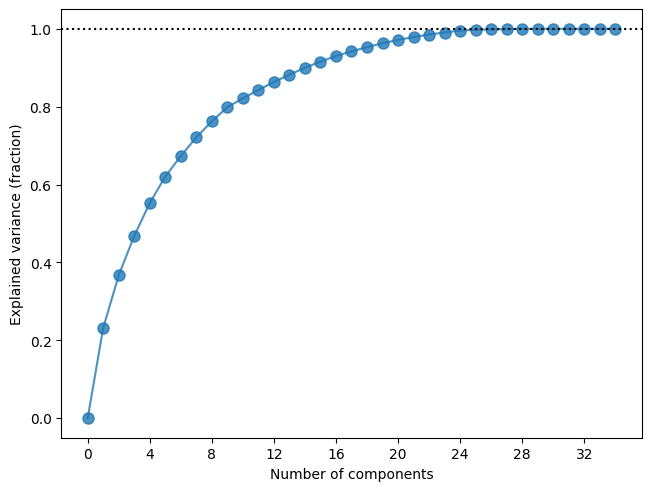

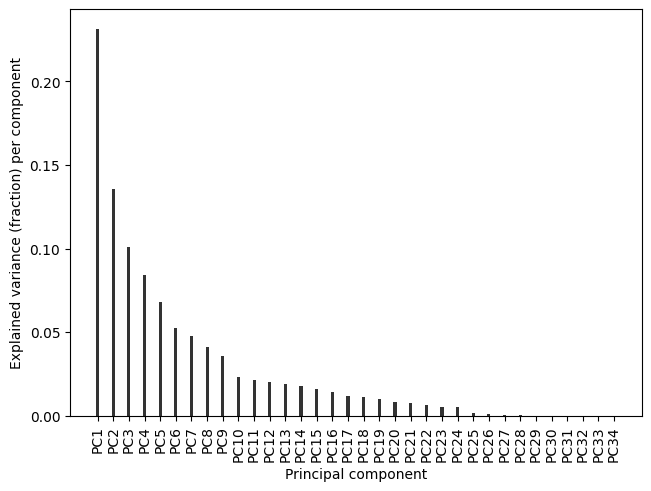

In [34]:

# perform PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_numeric_normalized)

from matplotlib import pyplot as plt
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

**Focus on the labor participation**

In [41]:
selected_columns = [
                    'mcsa_percent',
                    'mfccsa_percent',
                    'mc_infant_percent',
                  'mfcc_infant_percent',
                   'mc_tod_pre_percent',
                  'mfcc_tod_pre_percent' ,
                    'flfpr_20to64',
                    'flfpr_20to64_under6',
                    'flfpr_20to64_6to17',
                    'flfpr_20to64_under6_6to17']

In [42]:
from sklearn.cluster import KMeans

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')

# Apply K-Means to the scaled data and get cluster labels
cluster_labels = kmeans.fit_predict(df_numeric_normalized[selected_columns])

# Assign the cluster labels back to the correct rows in merged_df
merged_df['cluster_labels'] = cluster_labels

print("Cluster labels assigned to merged_df:")
print(merged_df['cluster_labels'].value_counts(dropna=False))

Cluster labels assigned to merged_df:
cluster_labels
0    21294
1    13273
Name: count, dtype: int64


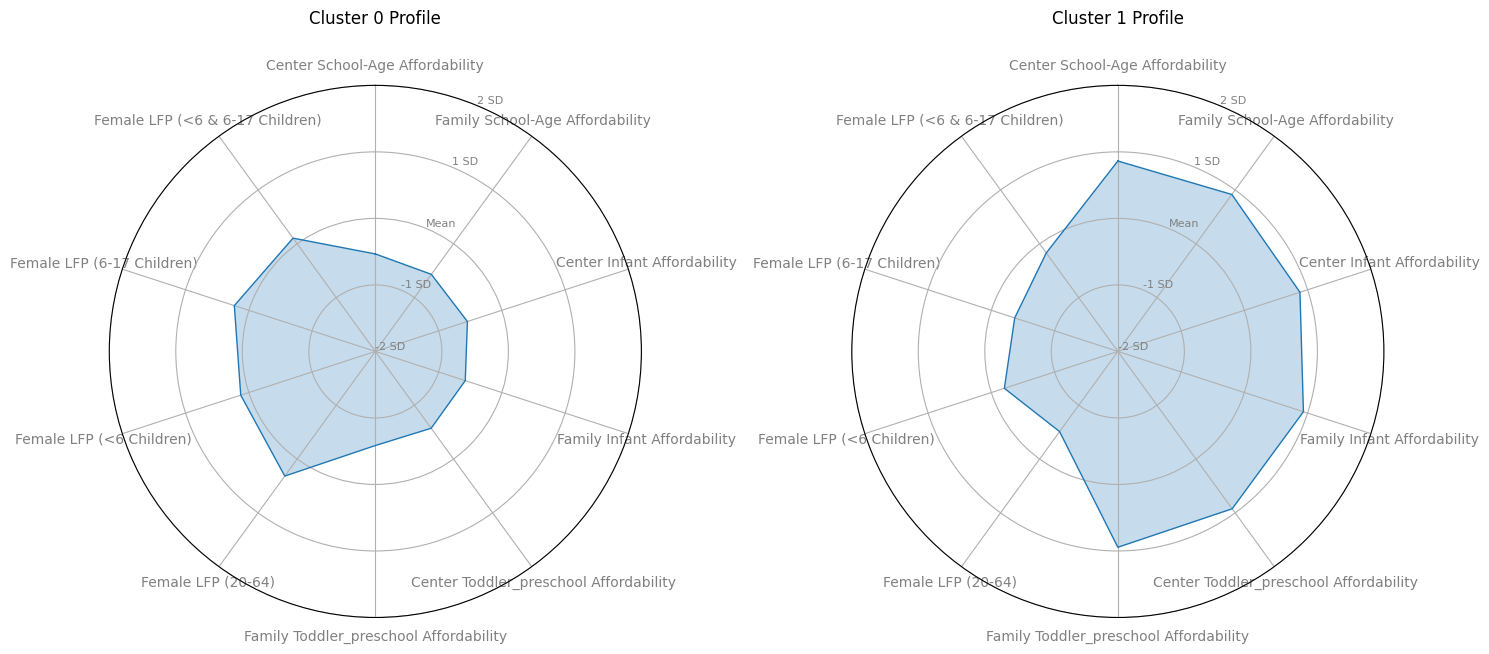

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for radar chart using scaled cluster centers for better comparison
# The 'selected_columns' list already contains the features for clustering
features = selected_columns
num_features = len(features)

# Get the scaled cluster centroids from the KMeans model
scaled_cluster_centroids = kmeans.cluster_centers_

# Create shorter, more readable labels for the features
feature_labels = [
    'Center School-Age Affordability',
    'Family School-Age Affordability',
    'Center Infant Affordability',
    'Family Infant Affordability',
    'Center Toddler_preschool Affordability',
    'Family Toddler_preschool Affordability',
    'Female LFP (20-64)',
    'Female LFP (<6 Children)',
    'Female LFP (6-17 Children)',
    'Female LFP (<6 & 6-17 Children)'
]

# Add the first feature to the end to close the circle in the radar chart
# This ensures the polygon connects back to the start
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1] # Complete the circle
feature_labels_plot = feature_labels + [feature_labels[0]]

fig, axes = plt.subplots(figsize=(15, 10), nrows=1, ncols=2, subplot_kw=dict(polar=True))
axes = axes.flatten()

# Plot each cluster on a separate radar chart
for i in range(n_clusters):
    cluster_label = i
    values = scaled_cluster_centroids[i].tolist()
    values += values[:1] # Complete the circle

    ax = axes[i]
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster_label}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(f'Cluster {cluster_label} Profile', size=12, color='black', y=1.1)

    # Set radial axis ticks (y-axis for polar plot)
    ax.set_yticks([-2, -1, 0, 1, 2]) # Example ticks for scaled data
    ax.set_yticklabels(['-2 SD', '-1 SD', 'Mean', '1 SD', '2 SD'], color='grey', size=8)
    ax.tick_params(axis='y', pad=10) # Adjust padding for y-axis labels

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, color='grey', size=10)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

plt.tight_layout()
plt.show()

**Remove labor force participation features**




In [ ]:
# Drop labor force participation features
df_numeric_normalized_2 = df_numeric_normalized.drop(columns=['flfpr_20to64','flfpr_20to64_under6', 'flfpr_20to64_6to17',
                                                              'flfpr_20to64_under6_6to17',
                                                              'mlfpr_20to64'])

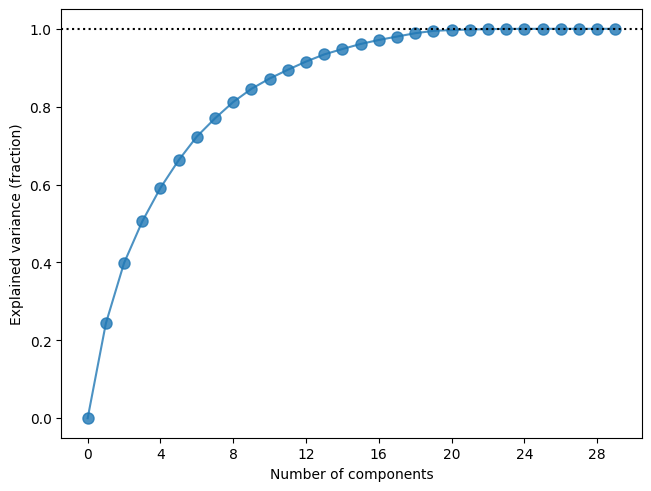

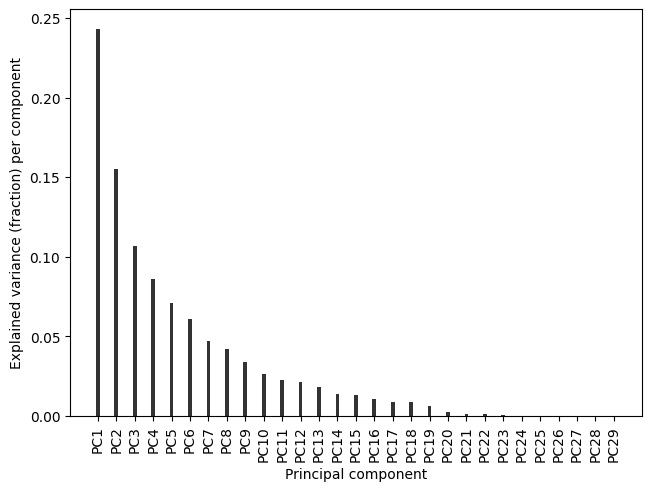

In [ ]:
# perform PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_numeric_normalized_2)

from matplotlib import pyplot as plt
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

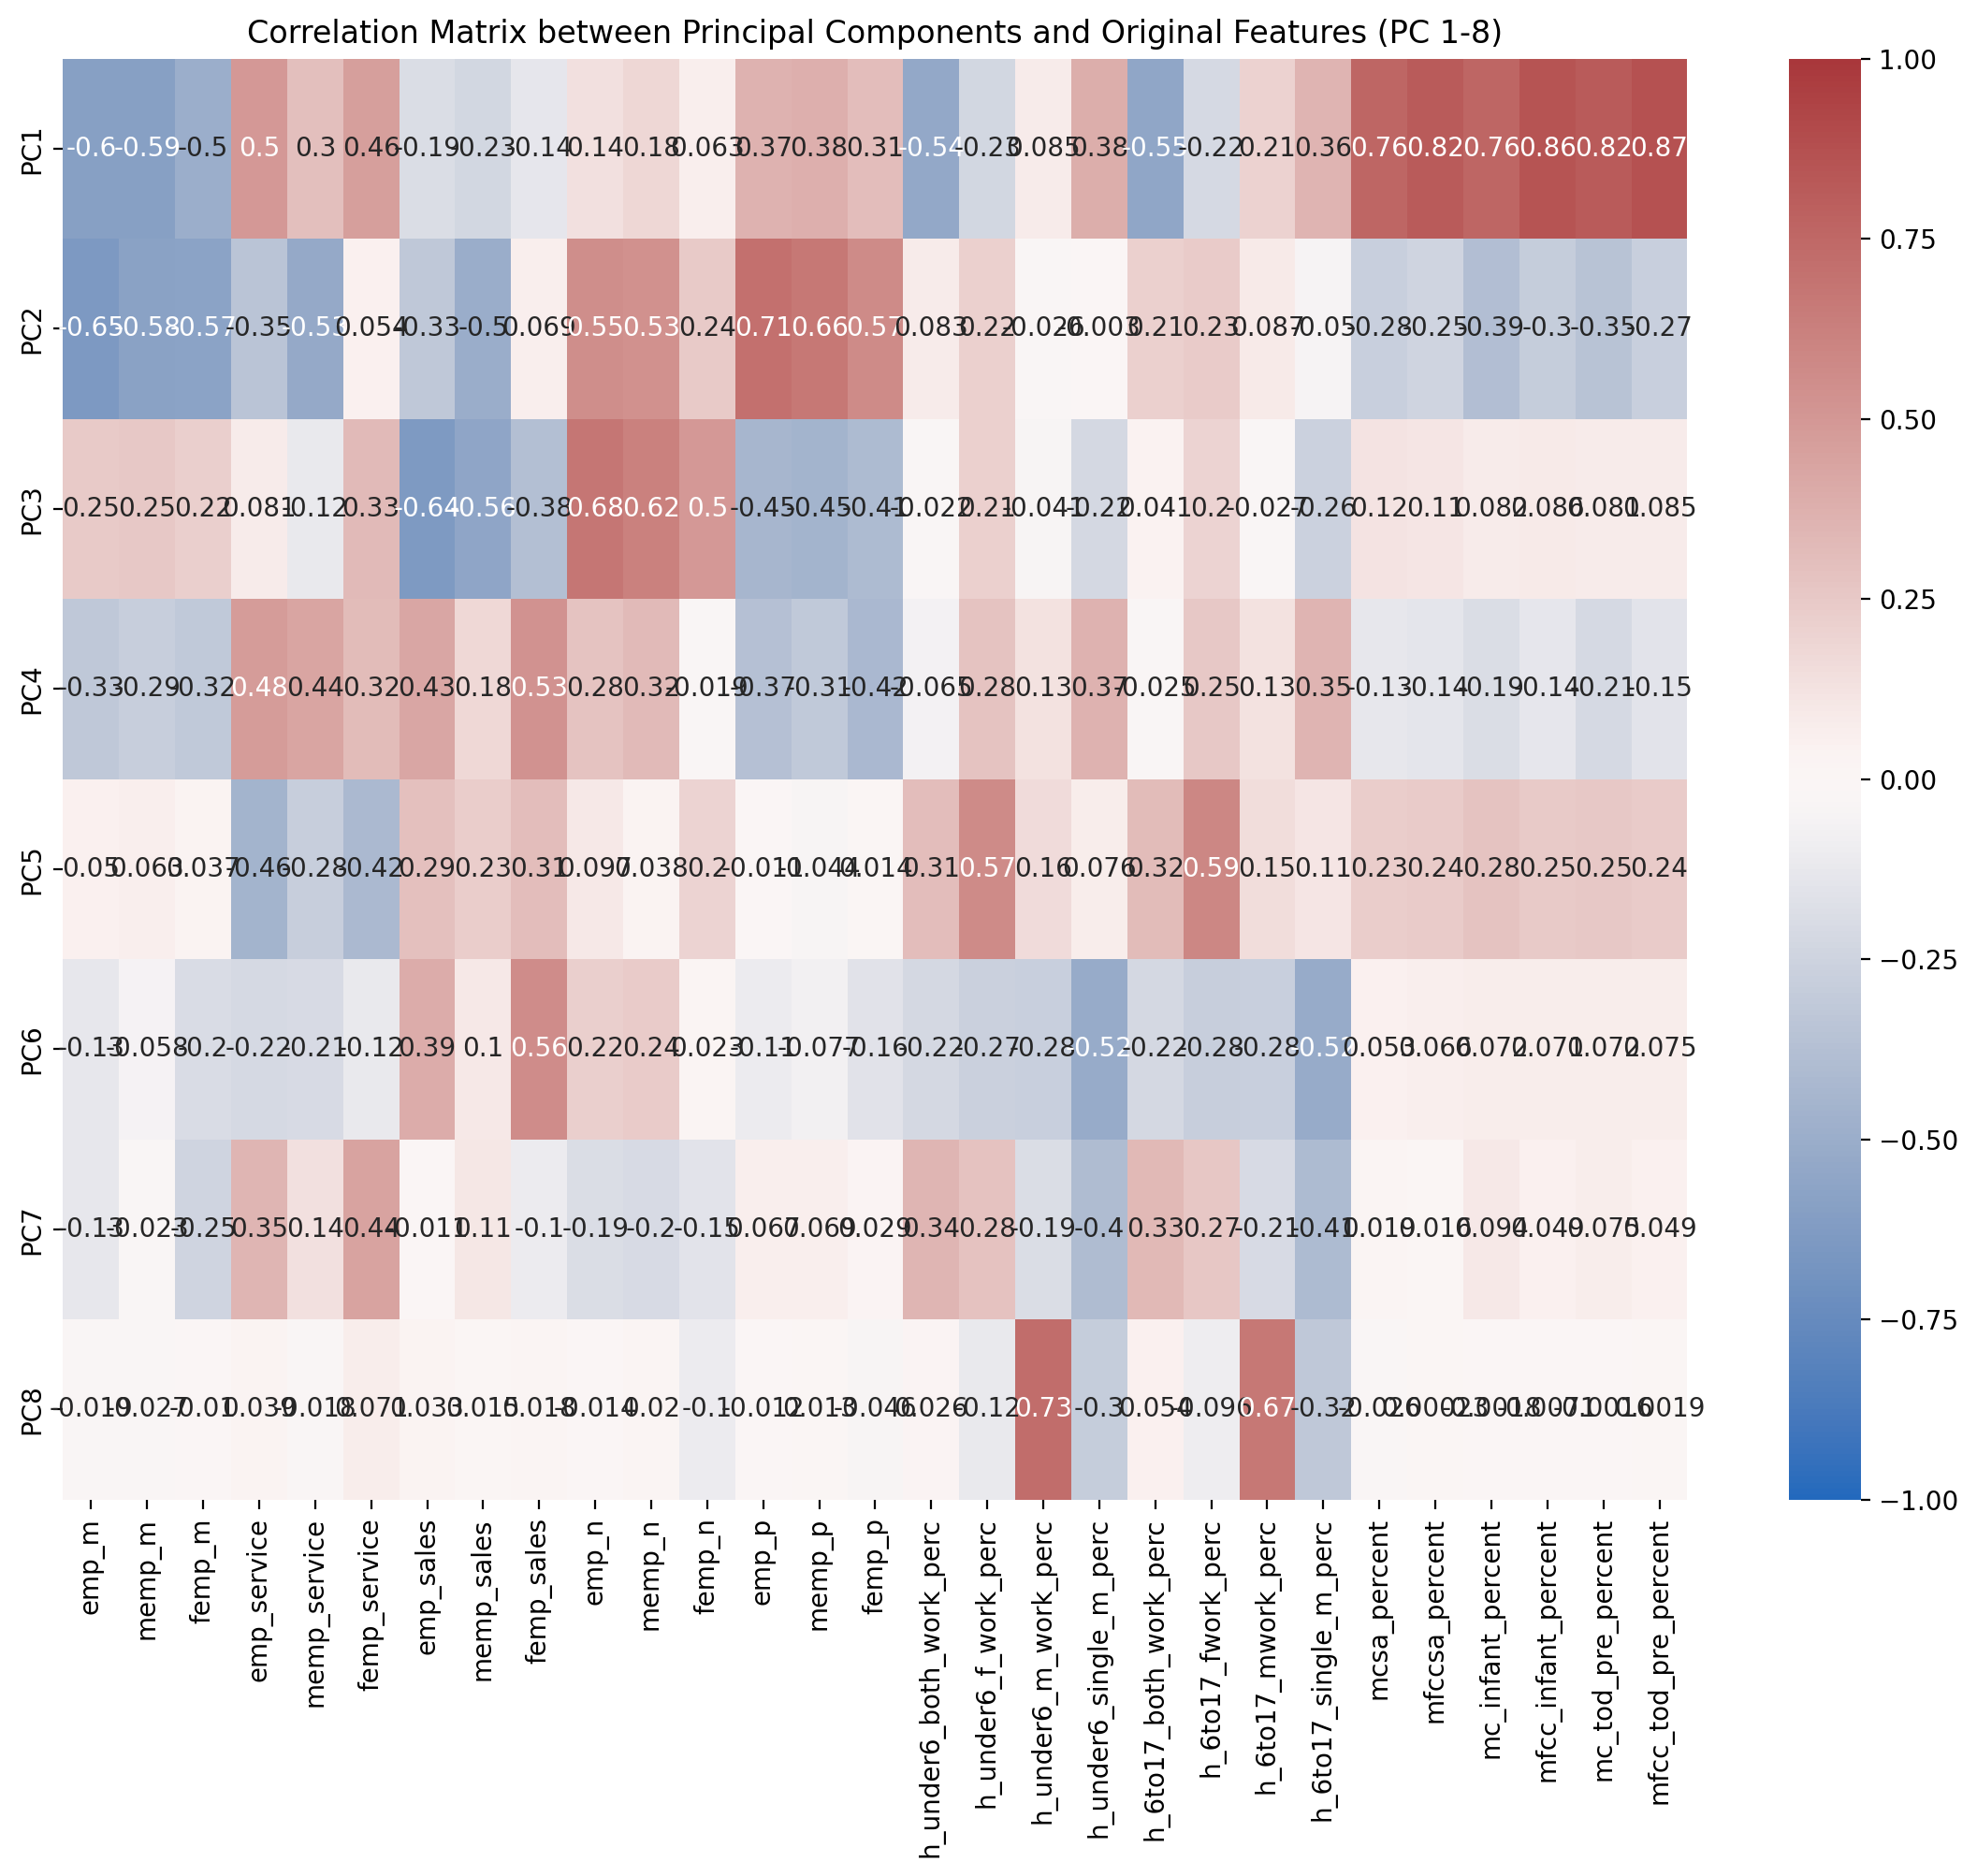

In [ ]:
# Check the correlation between PC 1- 8 and orifinal features
from seaborn import heatmap
import seaborn as sns

# Data represented in terms of PCs
transformed_data = pd.DataFrame(pca.transform(df_numeric_normalized_2), columns = ['PC' + str(i+1) for i in range(len(pca.components_))])

# Use only the first 8 PCs
transformed_data_8_pcs = transformed_data.iloc[:, :8]

# Concatenate the PCs and the normalized original features
combined_df = pd.concat([transformed_data_8_pcs, df_numeric_normalized_2.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix
correlation_pcs_original = combined_df.corr().loc[transformed_data_8_pcs.columns, df_numeric_normalized_2.columns]

plt.figure(figsize=(14,10), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features (PC 1-8)')
plt.show()

**Focuse on household composition**


In [ ]:
# Keep relevant features
df_numeric_normalized_3 = df_numeric_normalized[['h_under6_both_work_perc','h_under6_f_work_perc','h_under6_m_work_perc','h_under6_single_m_perc',
              'h_6to17_both_work_perc',	'h_6to17_fwork_perc',	'h_6to17_mwork_perc',	'h_6to17_single_m_perc',
               'mcsa_percent',	'mfccsa_percent','mc_infant_percent','mfcc_infant_percent',	'mc_tod_pre_percent',	'mfcc_tod_pre_percent'
                                                ]]

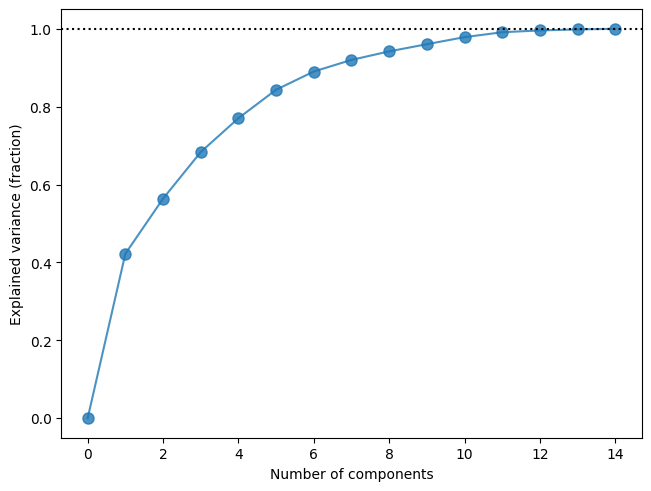

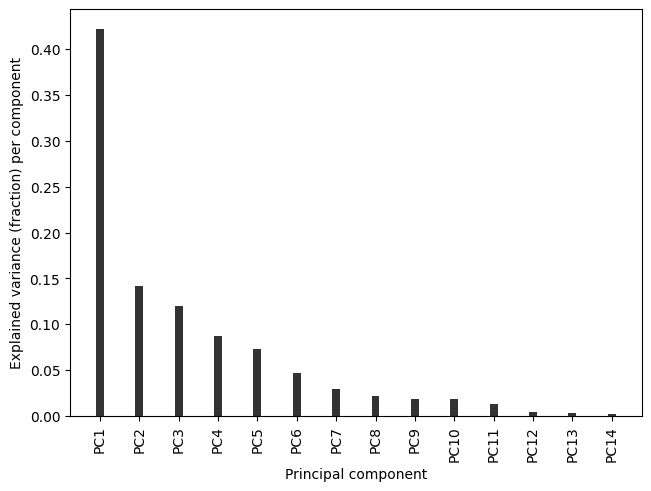

In [ ]:
# perform PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_numeric_normalized_3)

from matplotlib import pyplot as plt
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

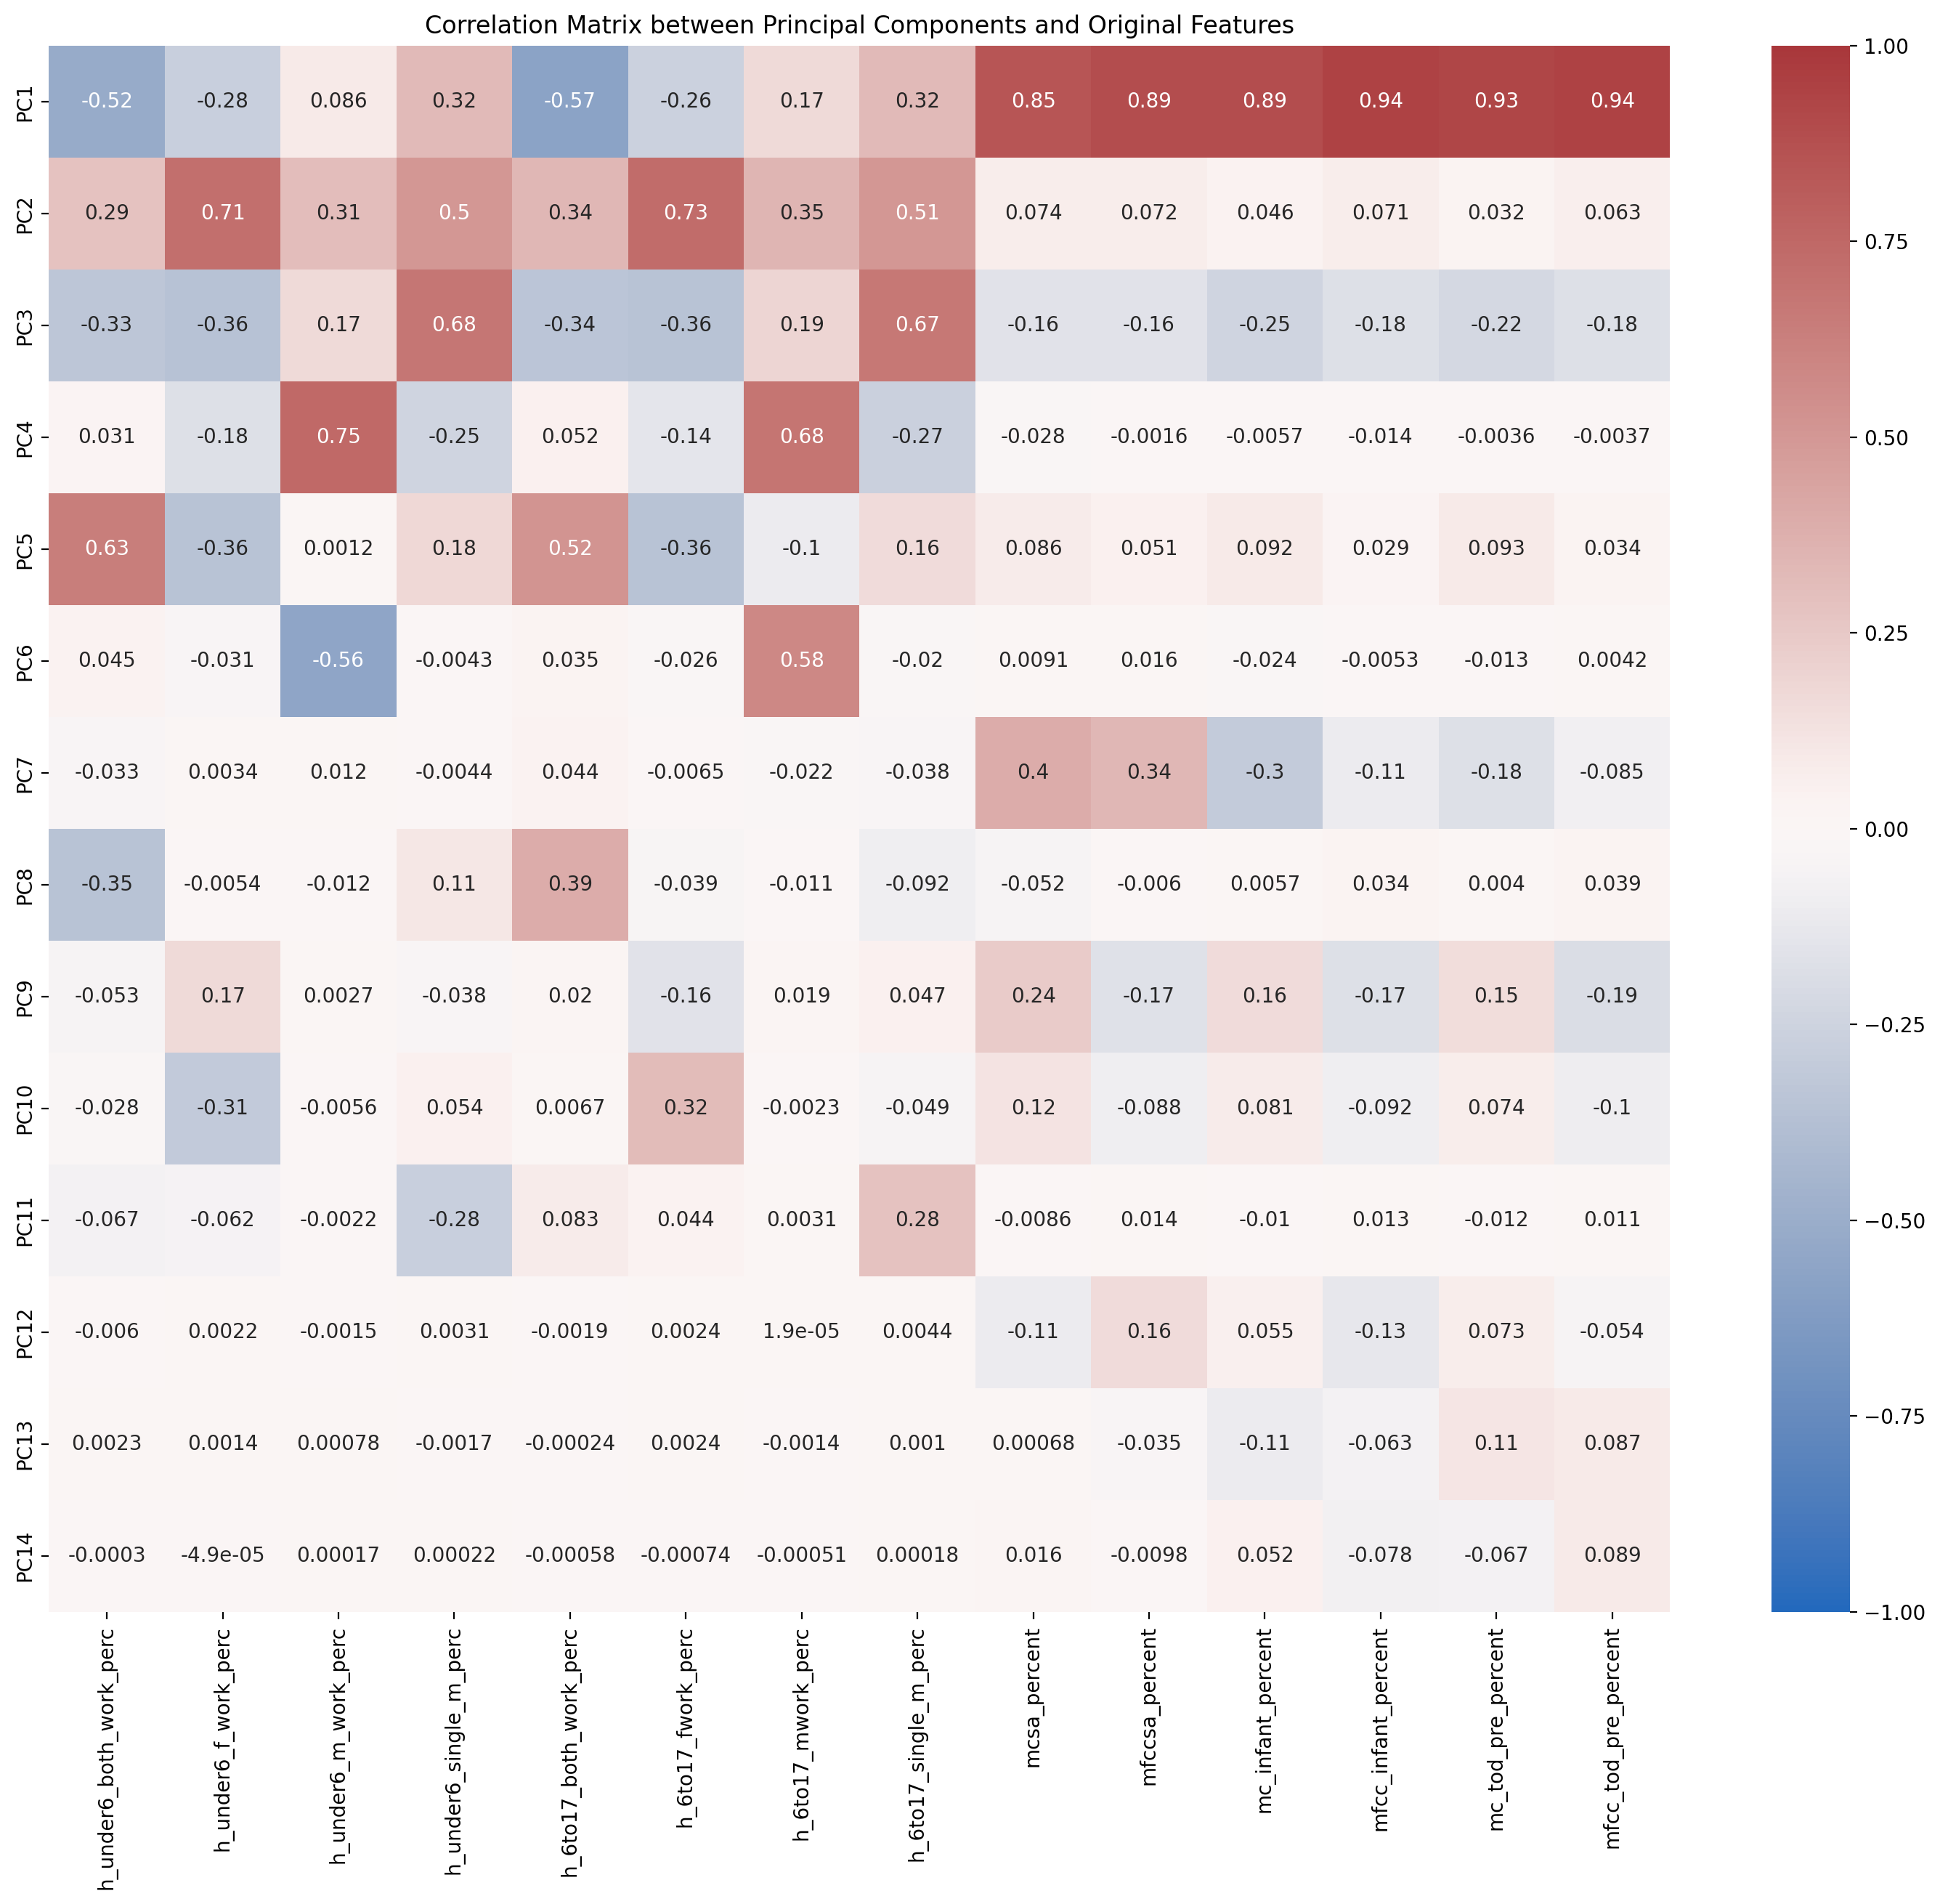

In [ ]:
from seaborn import heatmap
import seaborn as sns

# Data represented in terms of PCs
transformed_data = pd.DataFrame(pca.transform(df_numeric_normalized_3), columns = ['PC' + str(i+1) for i in range(len(pca.components_))])

# Use all PC
transformed_data_household = transformed_data

# Concatenate the selected PCs and the normalized original features (df_numeric_normalized_3)
combined_df = pd.concat([transformed_data_household, df_numeric_normalized_3.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix between all PCs and the features in df_numeric_normalized_3
correlation_pcs_original = combined_df.corr().loc[transformed_data_household.columns, df_numeric_normalized_3.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

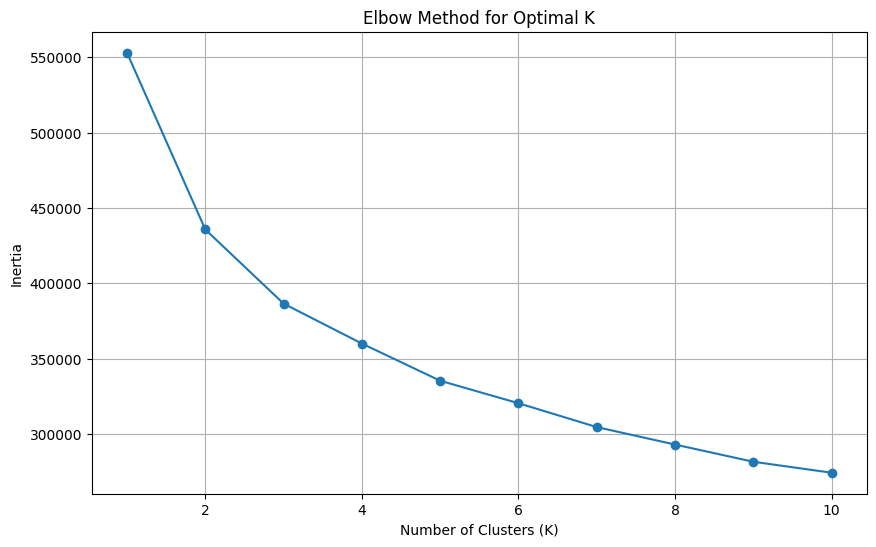

In [ ]:
# Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42,n_init='auto')
    model.fit(df_numeric_normalized_3)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


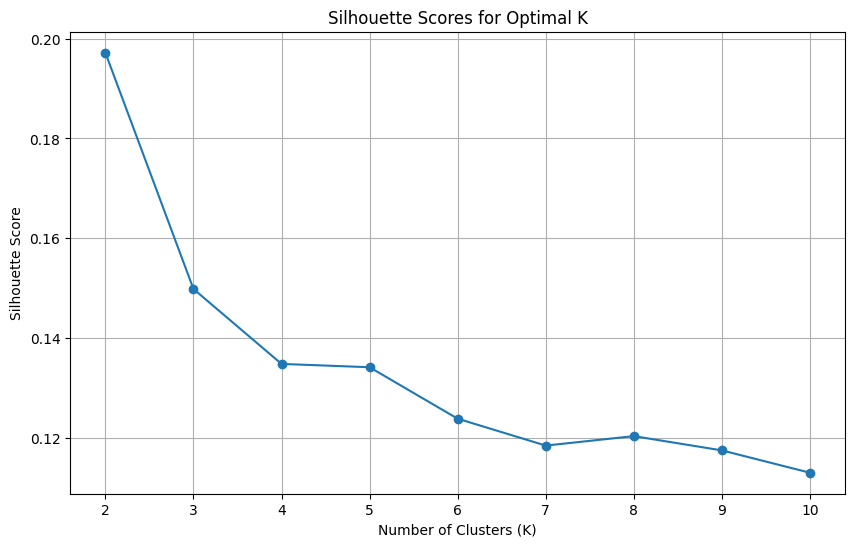

In [ ]:

# Apply silhouette_score
from sklearn.metrics import silhouette_score
silhouette_scores = []

# Calculate silhouette scores for k from 2 to 10 (silhouette score is not defined for k=1)
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = model.fit_predict(df_numeric_normalized_3)
    score = silhouette_score(df_numeric_normalized_3, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

**Focuse on occupation types**

In [ ]:
# Keep relevant features
df_numeric_normalized_4 = df_numeric_normalized[[
                 'memp_m','femp_m',
   'memp_service','femp_service',
   'memp_sales','femp_sales',
  'memp_n','femp_n',
    'memp_p','femp_p',
               'mcsa_percent',	'mfccsa_percent','mc_infant_percent','mfcc_infant_percent',	'mc_tod_pre_percent',	'mfcc_tod_pre_percent'
                                                ]]

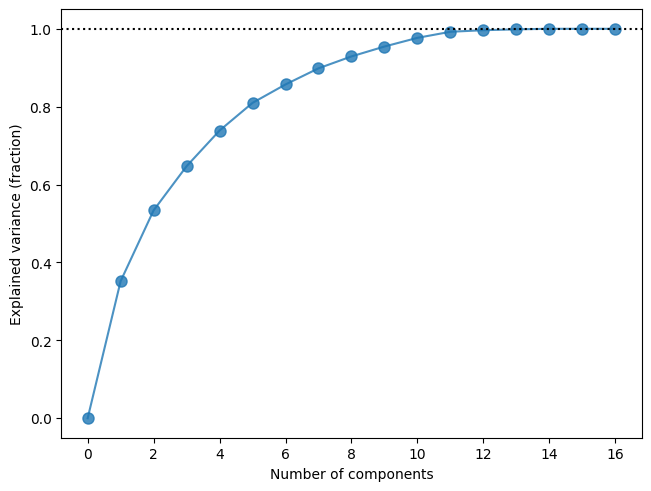

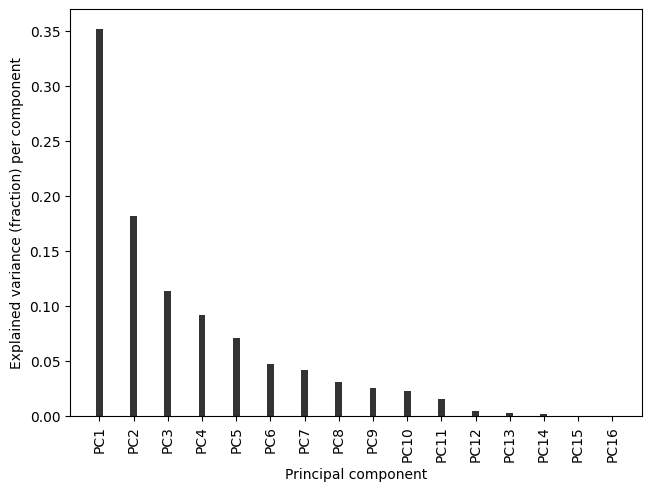

In [ ]:
# perform PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_numeric_normalized_4)

from matplotlib import pyplot as plt
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

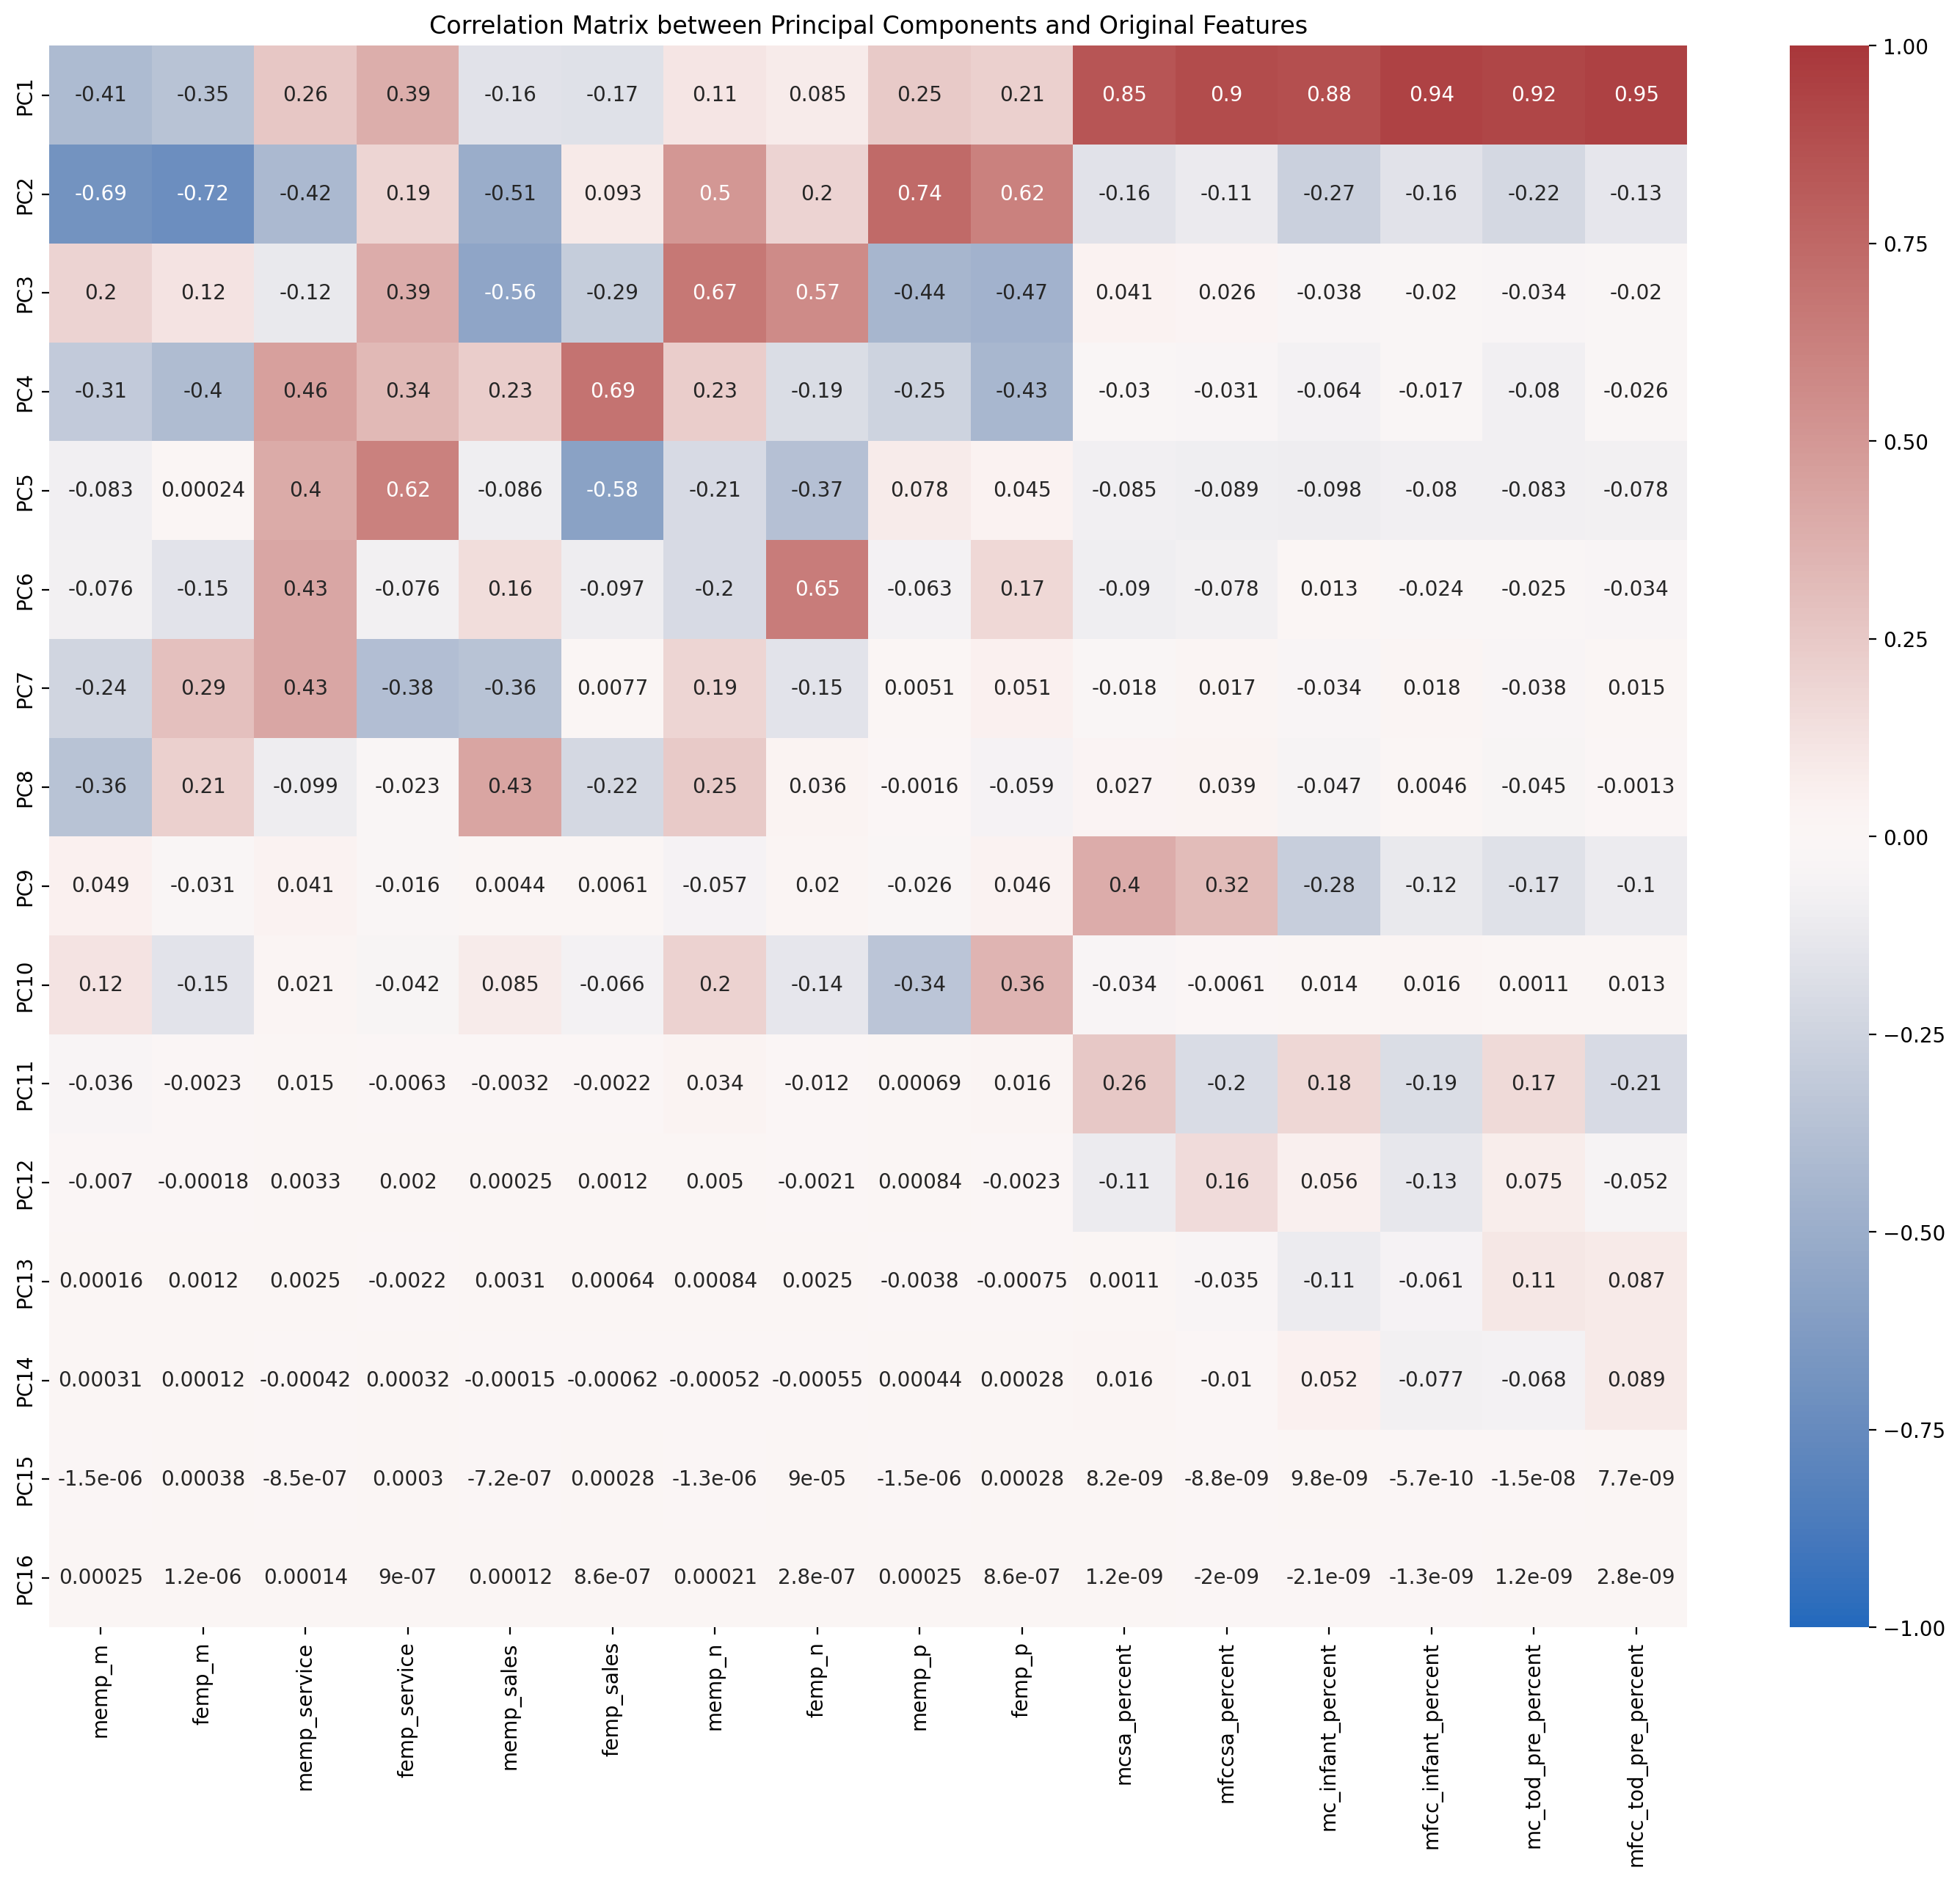

In [ ]:
from seaborn import heatmap
import seaborn as sns

# Data represented in terms of PCs
transformed_data = pd.DataFrame(pca.transform(df_numeric_normalized_4), columns = ['PC' + str(i+1) for i in range(len(pca.components_))])

# Use all PC
transformed_data_occup = transformed_data

# Concatenate the selected PCs and the normalized original features (df_numeric_normalized_3)
combined_df = pd.concat([transformed_data_occup, df_numeric_normalized_4.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix between all PCs and the features in df_numeric_normalized_3
correlation_pcs_original = combined_df.corr().loc[transformed_data_occup.columns, df_numeric_normalized_4.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

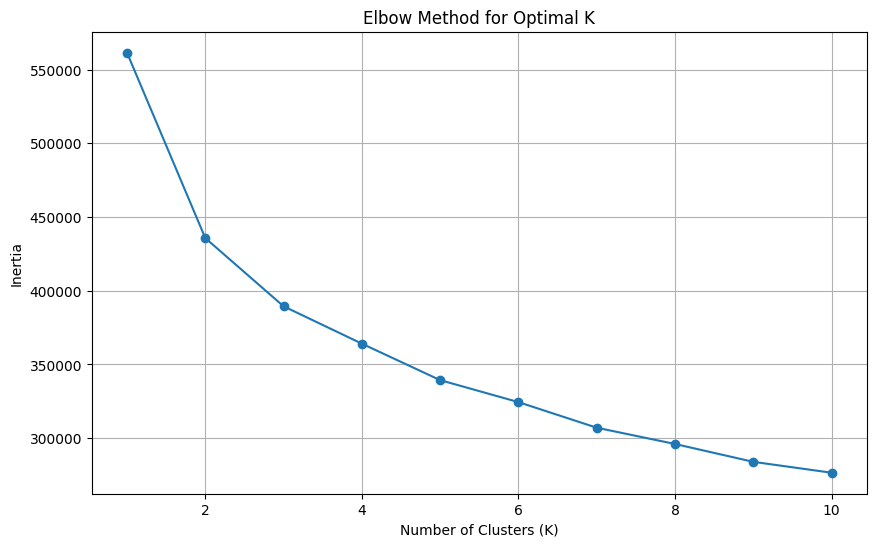

In [ ]:
# Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42,n_init='auto')
    model.fit(df_numeric_normalized_4)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


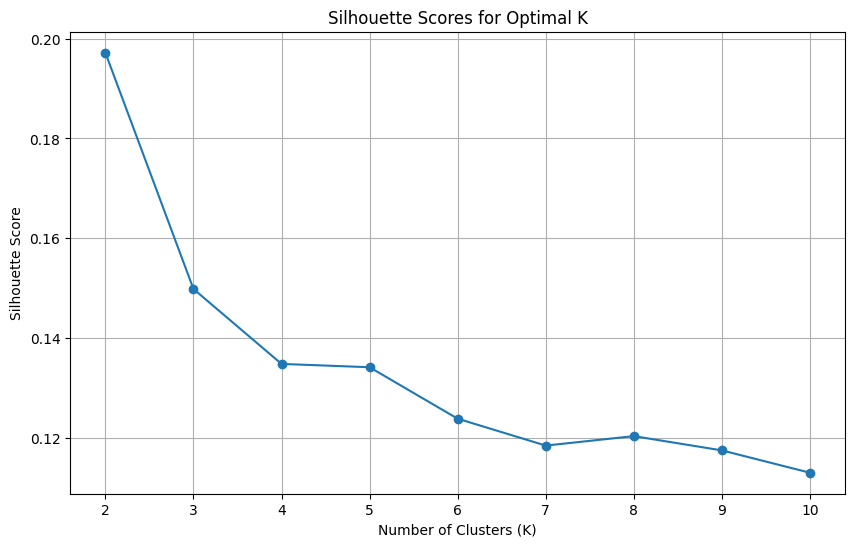

In [ ]:

# Apply silhouette_score
from sklearn.metrics import silhouette_score
silhouette_scores = []

# Calculate silhouette scores for k from 2 to 10 (silhouette score is not defined for k=1)
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = model.fit_predict(df_numeric_normalized_4)
    score = silhouette_score(df_numeric_normalized_4, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
# compare the clusters if k=2
model = KMeans(n_clusters=2, random_state=42, n_init='auto')
cluster_labels = model.fit_predict(df_numeric_normalized_4)
df_numeric_normalized_4['cluster'] = cluster_labels




/tmp/ipython-input-3964064743.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric_normalized_4['cluster'] = cluster_labels


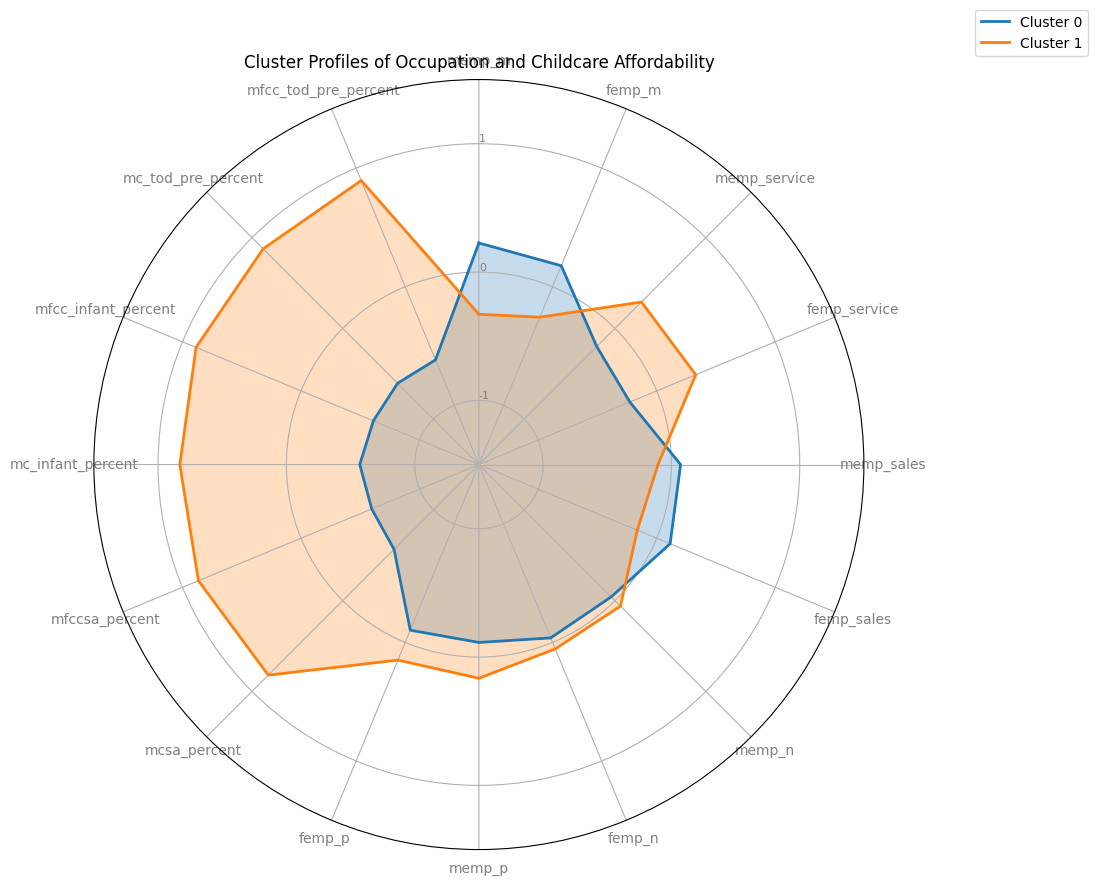

In [ ]:
import matplotlib.pyplot as plt

# Create shorter, more readable labels for the features
feature_labels_occu = [
    'Center School-Age Affordability',
    'Family School-Age Affordability',
    'Center Infant Affordability',
    'Family Infant Affordability',
    'Center Toddler_preschool Affordability',
    'Family Toddler_preschool Affordability',

]

def create_radar_chart(df, title):
    labels = df.columns.tolist()
    num_vars = len(labels)

    # Calculate angle for each axis
    angles = [n / float(num_vars) * 2 * 3.14159 for n in range(num_vars)]
    angles += angles[:1] # Complete the loop

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Plot each cluster
    for i, row in df.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {i}')
        ax.fill(angles, values, alpha=0.25)

    ax.set_theta_offset(3.14159 / 2)
    ax.set_theta_direction(-1)

    # Draw axis labels
    plt.xticks(angles[:-1], labels, color='grey', size=10)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([-1, 0, 1], ["-1", "0", "1"], color="grey", size=8)
    plt.ylim(-1.5, 1.5) # Adjust y-limits based on your data scale

    ax.set_title(title, va='bottom')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Create the radar chart for cluster centroids
create_radar_chart(cluster_centroids, 'Cluster Profiles of Occupation and Childcare Affordability')